# 05b — ResNet-50 Multi-label Dynamic GRL v2: Fast-Ramp Schedule

This notebook preserves the completed original **05 Dynamic GRL** experiment unchanged and evaluates a separate **fast-ramp Dynamic GRL v2** schedule.

It uses the **same fixed patient-level split, seven labels, ImageNet-pretrained ResNet-50 backbone, preprocessing, batch size, optimiser, losses, seed set, maximum epoch budget, validation-only threshold protocol, and test evaluation** as notebooks 03–05.

The only methodological change from the original Dynamic GRL is the schedule applied to the same `lambda_max = 0.1`:

- **Static GRL (04):** `lambda_adv = 0.1` throughout training.
- **Original Dynamic GRL (05):** DANN-style logistic ramp from 0 towards `0.1`.
- **Dynamic GRL v2 (this notebook):** `lambda_adv = 0` for the first 3% of training, then follows a smooth cosine ramp to `0.1` by 18% of training progress and remains at `0.1` thereafter.

This v2 experiment writes to a distinct `r50_dynamic_grl_fast_ramp_v2_*` output prefix and imports a distinct `r50_multilabel_final_common_v2.py` module. It does not overwrite the original notebook 05, its checkpoints, or its results.

The disease checkpoint is selected **only** by validation disease macro AUROC. The sex-head metrics are auxiliary representation diagnostics and are not used for checkpoint selection.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

from r50_multilabel_final_common_v2 import (
    MultiLabelAdversarialResNet50,
    base_run_config,
    build_label_fairness_summary,
    build_loaders,
    checkpoint_payload,
    compute_test_metrics_by_group,
    ensure_output_dirs,
    evaluate_adversarial,
    get_device,
    load_fixed_multilabel_data,
    make_disease_criterion,
    save_prediction_archive,
    seed_everything,
    select_per_label_thresholds,
    summarise_overall_fairness,
    train_dynamic_adv_one_epoch,
)

# Final experimental protocol: change values only before beginning a new full experiment.
FINAL_SEEDS = [42, 123, 2026]
BATCH_SIZE = 16
NUM_EPOCHS = 12

# This remains equal to the fixed static-GRL strength in notebook 04.
LAMBDA_MAX = 0.1

# v2 schedule: a brief warm-up followed by a fast smooth cosine ramp.
# lambda reaches LAMBDA_MAX at WARMUP_FRACTION + RAMP_FRACTION = 0.18.
WARMUP_FRACTION = 0.03
RAMP_FRACTION = 0.15

THRESHOLD_METRIC = "f1"
EXPERIMENT_ID = "r50_dynamic_grl_fast_ramp_v2_multiseed"

# Bootstrap is intentionally optional because it is computationally expensive.
# Enable it only after all three seed-level outputs have completed successfully.
RUN_PATIENT_CLUSTER_BOOTSTRAP = False
N_BOOTSTRAP = 1000
BOOTSTRAP_RANDOM_SEED = 202606

ensure_output_dirs()
Path("figures").mkdir(exist_ok=True)
device = get_device()

print("Device:", device)
print("Experiment ID:", EXPERIMENT_ID)
print("Seeds:", FINAL_SEEDS)
print("Dynamic GRL lambda_max:", LAMBDA_MAX)
print("Dynamic GRL v2 schedule:", "warm-up + fast cosine ramp")
print("Warm-up fraction:", WARMUP_FRACTION)
print("Ramp fraction:", RAMP_FRACTION)
print("Lambda reaches max at progress:", WARMUP_FRACTION + RAMP_FRACTION)


Device: mps
Experiment ID: r50_dynamic_grl_fast_ramp_v2_multiseed
Seeds: [42, 123, 2026]
Dynamic GRL lambda_max: 0.1
Dynamic GRL v2 schedule: warm-up + fast cosine ramp
Warm-up fraction: 0.03
Ramp fraction: 0.15
Lambda reaches max at progress: 0.18


## Load the frozen patient-level split and shared multi-label protocol


In [2]:
train_df, val_df, test_df, selected_labels, label_columns, audit_config = load_fixed_multilabel_data()

# The final protocol must not recreate, rebalance, or alter the existing split.
train_patients = set(train_df["Patient ID"].astype(str))
val_patients = set(val_df["Patient ID"].astype(str))
test_patients = set(test_df["Patient ID"].astype(str))
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

criterion_for_weights, pos_weight_table, pos_weight_values = make_disease_criterion(
    train_df, label_columns, device
)
del criterion_for_weights  # A fresh disease criterion is created for every seed-level run.
sex_criterion = torch.nn.BCEWithLogitsLoss()

print("Selected labels:", selected_labels)
print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Batch size:", BATCH_SIZE)
display(pos_weight_table)


Selected labels: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation']
Split sizes: {'train': 78873, 'validation': 10953, 'test': 22294}
Batch size: 16


,label,train_positive,train_negative,pos_weight
0,Infiltration,13868,65005,4.687410
1,Effusion,9533,69340,7.273681
2,Atelectasis,8262,70611,8.546478
3,Nodule,4415,74458,16.864779
4,Mass,4199,74674,17.783758
5,Pneumothorax,3841,75032,19.534496
6,Consolidation,3280,75593,23.046646


## Seed-level Dynamic GRL v2 training, validation-only thresholding, and final test evaluation

The model architecture and total loss are identical to Static GRL and the original Dynamic GRL. The only change in this notebook is the schedule used by the Gradient Reversal Layer: after a short zero-adversary warm-up, `lambda_adv` rises smoothly to the same `lambda_max = 0.1` early in training and remains fixed there.

The total loss remains:

```text
disease_loss + sex_loss
```

`lambda_adv` is applied only inside the Gradient Reversal Layer. It is **not** multiplied again outside the GRL.


In [3]:
def run_dynamic_grl_fast_ramp_v2_seed(seed: int):
    """Train one independent fast-ramp Dynamic-GRL v2 run and save all seed-level artefacts."""
    seed_everything(seed)
    run_tag = f"r50_dynamic_grl_fast_ramp_v2_seed{seed}"
    output_prefix = Path("results") / run_tag
    best_model_path = Path("checkpoints") / f"{run_tag}_best.pt"

    train_loader, val_loader, test_loader = build_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_columns=label_columns,
        seed=seed,
        batch_size=BATCH_SIZE,
    )

    model = MultiLabelAdversarialResNet50(n_labels=len(selected_labels)).to(device)
    feature_dim = model.feature_dim
    disease_criterion, _, _ = make_disease_criterion(train_df, label_columns, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    total_steps = NUM_EPOCHS * len(train_loader)
    run_config = base_run_config(
        seed=seed,
        selected_labels=selected_labels,
        feature_dim=feature_dim,
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        pos_weight_values=pos_weight_values,
        checkpoint_path=best_model_path,
    )
    run_config.update(
        {
            "experiment_id": EXPERIMENT_ID,
            "model_variant": "r50_dynamic_grl_fast_ramp_v2",
            "adversarial_training": True,
            "adversarial_schedule": "short warm-up plus fast cosine ramp",
            "lambda_max": float(LAMBDA_MAX),
            "warmup_fraction": float(WARMUP_FRACTION),
            "ramp_fraction": float(RAMP_FRACTION),
            "schedule_reaches_lambda_max_at_progress": float(WARMUP_FRACTION + RAMP_FRACTION),
            "schedule_initial_lambda": 0.0,
            "schedule_total_training_steps": int(total_steps),
            "static_comparison_lambda_adv": float(LAMBDA_MAX),
            "sex_head": "Linear(feature_dim, 1)",
            "sex_loss": "BCEWithLogitsLoss",
            "total_loss": "disease_loss + sex_loss; lambda_adv applied only by GRL",
            "threshold_metric": f"validation_{THRESHOLD_METRIC}",
            "audit_config_source": "results/multilabel_selected_labels.json",
            "core_selection_rules": audit_config.get("core_selection_rules", {}),
        }
    )

    print(f"\n{'=' * 76}\nStarting {run_tag}")
    print("Disease head:", model.disease_head)
    print("Sex head:", model.sex_head)
    print("feature_dim obtained from base.fc.in_features:", feature_dim)
    print(
        f"Schedule: lambda_max={LAMBDA_MAX}, warmup={WARMUP_FRACTION}, "
        f"ramp={RAMP_FRACTION}, reaches max at progress="
        f"{WARMUP_FRACTION + RAMP_FRACTION:.2f}, total_steps={total_steps}"
    )

    history = []
    schedule_rows = []
    best_val_macro_auroc = -np.inf
    best_epoch = None
    global_step = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_results = train_dynamic_adv_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            disease_criterion=disease_criterion,
            sex_criterion=sex_criterion,
            device=device,
            epoch=epoch,
            global_step=global_step,
            total_steps=total_steps,
            lambda_max=LAMBDA_MAX,
            warmup_fraction=WARMUP_FRACTION,
            ramp_fraction=RAMP_FRACTION,
        )
        global_step = train_results["global_step"]
        for row in train_results["schedule_rows"]:
            row["seed"] = seed
            row["model_variant"] = "r50_dynamic_grl_fast_ramp_v2"
        schedule_rows.extend(train_results["schedule_rows"])

        val_results = evaluate_adversarial(
            model=model,
            loader=val_loader,
            disease_criterion=disease_criterion,
            sex_criterion=sex_criterion,
            device=device,
            labels=selected_labels,
        )

        history_row = {
            "seed": seed,
            "epoch": epoch,
            "lambda_start": train_results["lambda_start"],
            "lambda_end": train_results["lambda_end"],
            "lambda_mean": train_results["lambda_mean"],
            "train_loss": train_results["loss"],
            "train_disease_loss": train_results["disease_loss"],
            "train_sex_loss": train_results["sex_loss"],
            "val_loss": val_results["loss"],
            "val_disease_loss": val_results["disease_loss"],
            "val_sex_loss": val_results["sex_loss"],
            "val_macro_auroc": val_results["disease_macro_auroc"],
            "val_macro_auprc": val_results["disease_macro_auprc"],
            "val_sex_auroc": val_results["sex_auroc"],
            "val_sex_accuracy": val_results["sex_accuracy"],
        }
        history.append(history_row)

        print(
            f"Seed {seed} | Epoch {epoch}/{NUM_EPOCHS} | "
            f"lambda={train_results['lambda_start']:.4f}->{train_results['lambda_end']:.4f} "
            f"(mean={train_results['lambda_mean']:.4f}) | "
            f"train disease loss={train_results['disease_loss']:.4f} | "
            f"val disease macro AUROC={val_results['disease_macro_auroc']:.4f} | "
            f"val disease macro AUPRC={val_results['disease_macro_auprc']:.4f} | "
            f"val sex AUROC={val_results['sex_auroc']:.4f} | "
            f"val sex accuracy={val_results['sex_accuracy']:.4f}"
        )

        if val_results["disease_macro_auroc"] > best_val_macro_auroc:
            best_val_macro_auroc = float(val_results["disease_macro_auroc"])
            best_epoch = epoch
            torch.save(
                checkpoint_payload(model, epoch, best_val_macro_auroc, run_config),
                best_model_path,
            )
            print("  Saved checkpoint selected by validation disease macro AUROC.")

    if best_epoch is None:
        raise RuntimeError(f"No checkpoint was saved for seed {seed}.")

    history_df = pd.DataFrame(history)
    schedule_df = pd.DataFrame(schedule_rows)

    # Load only the validation-selected checkpoint before selecting thresholds or evaluating test performance.
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device).eval()

    val_final = evaluate_adversarial(
        model=model,
        loader=val_loader,
        disease_criterion=disease_criterion,
        sex_criterion=sex_criterion,
        device=device,
        labels=selected_labels,
    )
    test_final = evaluate_adversarial(
        model=model,
        loader=test_loader,
        disease_criterion=disease_criterion,
        sex_criterion=sex_criterion,
        device=device,
        labels=selected_labels,
    )

    assert len(val_final["probs"]) == len(val_df), "Threshold selection must use the complete validation set."
    assert len(test_final["probs"]) == len(test_df), "Test prediction count mismatch."
    assert len(schedule_df) == total_steps, "Dynamic schedule must record every training step."

    thresholds_df = select_per_label_thresholds(
        probs=val_final["probs"],
        targets=val_final["targets"],
        labels=selected_labels,
        metric=THRESHOLD_METRIC,
    )
    test_overall_by_label, test_subgroup_metrics = compute_test_metrics_by_group(
        probs=test_final["probs"],
        targets=test_final["targets"],
        sexes=test_final["sexes"],
        labels=selected_labels,
        thresholds_df=thresholds_df,
    )
    label_fairness_summary = build_label_fairness_summary(
        overall_metrics=test_overall_by_label,
        subgroup_metrics=test_subgroup_metrics,
        model_name="r50_dynamic_grl_fast_ramp_v2",
    )
    fairness_means = summarise_overall_fairness(label_fairness_summary)

    # Seed metadata is included in every exported table to support later multi-seed aggregation.
    for frame in [test_overall_by_label, test_subgroup_metrics, label_fairness_summary]:
        frame.insert(0, "seed", seed)
        frame.insert(0, "model_variant", "r50_dynamic_grl_fast_ramp_v2")

    overall_result = pd.DataFrame(
        [
            {
                "model_variant": "r50_dynamic_grl_fast_ramp_v2",
                "model": "r50_dynamic_grl_fast_ramp_v2",
                "seed": seed,
                "n_labels": len(selected_labels),
                "selected_labels": "|".join(selected_labels),
                "lambda_max": float(LAMBDA_MAX),
                "warmup_fraction": float(WARMUP_FRACTION),
                "ramp_fraction": float(RAMP_FRACTION),
                "schedule_reaches_lambda_max_at_progress": float(
                    WARMUP_FRACTION + RAMP_FRACTION
                ),
                "best_epoch": int(best_epoch),
                "best_val_macro_auroc": float(best_val_macro_auroc),
                "test_macro_auroc": float(test_final["disease_macro_auroc"]),
                "test_macro_auprc": float(test_final["disease_macro_auprc"]),
                "test_sex_auroc": float(test_final["sex_auroc"]),
                "test_sex_accuracy": float(test_final["sex_accuracy"]),
                **fairness_means,
            }
        ]
    )

    # Persist every item needed for reproducibility, multi-seed summaries, schedule plots, and bootstrap CIs.
    pos_weight_table.to_csv(f"{output_prefix}_pos_weights.csv", index=False)
    history_df.to_csv(f"{output_prefix}_training_history.csv", index=False)
    schedule_df.to_csv(f"{output_prefix}_lambda_schedule_stepwise.csv", index=False)
    thresholds_df.to_csv(f"{output_prefix}_thresholds.csv", index=False)
    test_overall_by_label.to_csv(f"{output_prefix}_test_label_metrics.csv", index=False)
    test_subgroup_metrics.to_csv(f"{output_prefix}_subgroup_metrics.csv", index=False)
    label_fairness_summary.to_csv(f"{output_prefix}_label_fairness_summary.csv", index=False)
    overall_result.to_csv(f"{output_prefix}_overall_results.csv", index=False)

    run_config.update(
        {
            "best_epoch": int(best_epoch),
            "best_validation_macro_auroc": float(best_val_macro_auroc),
            "final_validation_macro_auroc": float(val_final["disease_macro_auroc"]),
            "final_validation_macro_auprc": float(val_final["disease_macro_auprc"]),
            "final_validation_sex_auroc": float(val_final["sex_auroc"]),
            "final_validation_sex_accuracy": float(val_final["sex_accuracy"]),
            "test_macro_auroc": float(test_final["disease_macro_auroc"]),
            "test_macro_auprc": float(test_final["disease_macro_auprc"]),
            "test_sex_auroc": float(test_final["sex_auroc"]),
            "test_sex_accuracy": float(test_final["sex_accuracy"]),
            "lambda_final_step": float(schedule_df["lambda_adv"].iloc[-1]),
        }
    )
    with open(f"{output_prefix}_run_config.json", "w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=2)

    save_prediction_archive(
        f"{output_prefix}_validation_predictions.npz",
        val_final,
        selected_labels,
        adversarial=True,
    )
    save_prediction_archive(
        f"{output_prefix}_test_predictions.npz",
        test_final,
        selected_labels,
        adversarial=True,
    )

    print(f"\nCompleted {run_tag}")
    print("Best epoch:", best_epoch)
    print("Test macro AUROC:", test_final["disease_macro_auroc"])
    print("Test macro AUPRC:", test_final["disease_macro_auprc"])
    print("Test sex-head AUROC:", test_final["sex_auroc"])
    print("Test sex-head accuracy:", test_final["sex_accuracy"])
    display(overall_result)

    return {
        "seed": seed,
        "run_tag": run_tag,
        "output_prefix": str(output_prefix),
        "overall_result": overall_result,
        "test_label_metrics": test_overall_by_label,
        "subgroup_metrics": test_subgroup_metrics,
        "label_fairness_summary": label_fairness_summary,
        "schedule": schedule_df,
    }


## Run the three independent fast-ramp Dynamic GRL v2 experiments

In [4]:
seed_runs = [run_dynamic_grl_fast_ramp_v2_seed(seed) for seed in FINAL_SEEDS]


Starting r50_dynamic_grl_fast_ramp_v2_seed42
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, warmup=0.03, ramp=0.15, reaches max at progress=0.18, total_steps=59160
Seed 42 | Epoch 1/12 | lambda=0.0000->0.0281 (mean=0.0062) | train disease loss=1.0377 | val disease macro AUROC=0.7905 | val disease macro AUPRC=0.2791 | val sex AUROC=0.5727 | val sex accuracy=0.5650
  Saved checkpoint selected by validation disease macro AUROC.
Seed 42 | Epoch 2/12 | lambda=0.0281->0.0981 (mean=0.0678) | train disease loss=0.9550 | val disease macro AUROC=0.8045 | val disease macro AUPRC=0.2895 | val sex AUROC=0.4706 | val sex accuracy=0.5228
  Saved checkpoint selected by validation disease macro AUROC.
Seed 42 | Epoch 3/12 | lambda=0.0981->0.1000 (mean=0.0999) | train disease loss=0.9044 | val disease macro AUROC=0.8075 | val disease macro AUPRC=

,model_variant,model,seed,n_labels,selected_labels,lambda_max,warmup_fraction,ramp_fraction,schedule_reaches_lambda_max_at_progress,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,42,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.807459,0.809939,0.310254,0.563127,0.588454,0.042587,0.014605,0.042587,0.468447,0.013129



Starting r50_dynamic_grl_fast_ramp_v2_seed123
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, warmup=0.03, ramp=0.15, reaches max at progress=0.18, total_steps=59160
Seed 123 | Epoch 1/12 | lambda=0.0000->0.0281 (mean=0.0062) | train disease loss=1.0427 | val disease macro AUROC=0.7949 | val disease macro AUPRC=0.2776 | val sex AUROC=0.5214 | val sex accuracy=0.5452
  Saved checkpoint selected by validation disease macro AUROC.
Seed 123 | Epoch 2/12 | lambda=0.0281->0.0981 (mean=0.0678) | train disease loss=0.9585 | val disease macro AUROC=0.7943 | val disease macro AUPRC=0.2865 | val sex AUROC=0.5382 | val sex accuracy=0.5528
Seed 123 | Epoch 3/12 | lambda=0.0981->0.1000 (mean=0.0999) | train disease loss=0.9040 | val disease macro AUROC=0.8095 | val disease macro AUPRC=0.2981 | val sex AUROC=0.4987 | val sex accuracy=0.5232
  S

,model_variant,model,seed,n_labels,selected_labels,lambda_max,warmup_fraction,ramp_fraction,schedule_reaches_lambda_max_at_progress,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,123,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.809489,0.807057,0.30501,0.533967,0.539562,0.049964,0.024891,0.053688,0.439961,0.012271



Starting r50_dynamic_grl_fast_ramp_v2_seed2026
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, warmup=0.03, ramp=0.15, reaches max at progress=0.18, total_steps=59160
Seed 2026 | Epoch 1/12 | lambda=0.0000->0.0281 (mean=0.0062) | train disease loss=1.0454 | val disease macro AUROC=0.7888 | val disease macro AUPRC=0.2709 | val sex AUROC=0.5414 | val sex accuracy=0.5300
  Saved checkpoint selected by validation disease macro AUROC.
Seed 2026 | Epoch 2/12 | lambda=0.0281->0.0981 (mean=0.0678) | train disease loss=0.9599 | val disease macro AUROC=0.8002 | val disease macro AUPRC=0.2878 | val sex AUROC=0.5458 | val sex accuracy=0.5575
  Saved checkpoint selected by validation disease macro AUROC.
Seed 2026 | Epoch 3/12 | lambda=0.0981->0.1000 (mean=0.0999) | train disease loss=0.9036 | val disease macro AUROC=0.8109 | val disease macr

,model_variant,model,seed,n_labels,selected_labels,lambda_max,warmup_fraction,ramp_fraction,schedule_reaches_lambda_max_at_progress,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,2026,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.810856,0.809957,0.305822,0.536281,0.583924,0.040312,0.01099,0.040312,0.451532,0.0104


## Save and plot the Dynamic GRL v2 fast-ramp schedule

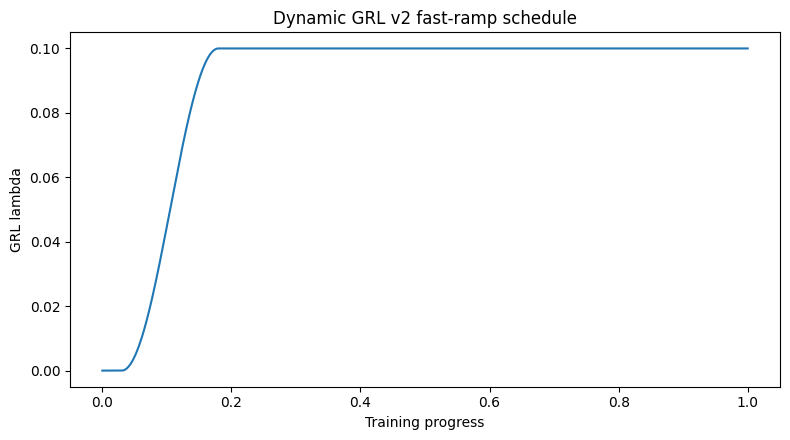

,global_step,progress,lambda_adv_mean,lambda_adv_std
0,0,0.000000,0.0,0.0
1,1,0.000017,0.0,0.0
2,2,0.000034,0.0,0.0
3,3,0.000051,0.0,0.0
4,4,0.000068,0.0,0.0


,global_step,progress,lambda_adv_mean,lambda_adv_std
59155,59155,0.999932,0.1,0.0
59156,59156,0.999949,0.1,0.0
59157,59157,0.999966,0.1,0.0
59158,59158,0.999983,0.1,0.0
59159,59159,1.000000,0.1,0.0


In [5]:
schedule_all = pd.concat([run["schedule"] for run in seed_runs], ignore_index=True)
schedule_summary = (
    schedule_all.groupby(["global_step", "progress"], as_index=False)
    .agg(
        lambda_adv_mean=("lambda_adv", "mean"),
        lambda_adv_std=("lambda_adv", "std"),
    )
)

schedule_all.to_csv(
    "results/r50_dynamic_grl_fast_ramp_v2_multiseed_lambda_schedule_stepwise.csv",
    index=False,
)
schedule_summary.to_csv(
    "results/r50_dynamic_grl_fast_ramp_v2_multiseed_lambda_schedule_mean_std.csv",
    index=False,
)

plt.figure(figsize=(8, 4.5))
plt.plot(schedule_summary["progress"], schedule_summary["lambda_adv_mean"])
plt.xlabel("Training progress")
plt.ylabel("GRL lambda")
plt.title("Dynamic GRL v2 fast-ramp schedule")
plt.tight_layout()
plt.savefig("figures/r50_dynamic_grl_fast_ramp_v2_lambda_schedule.png", dpi=300)
plt.show()

display(schedule_summary.head())
display(schedule_summary.tail())


## Aggregate multi-seed Dynamic GRL v2 results

In [6]:
def aggregate_mean_std(df: pd.DataFrame, group_columns, metric_columns) -> pd.DataFrame:
    """Aggregate completed seed-level results into mean and sample standard deviation."""
    metric_columns = [c for c in metric_columns if c in df.columns]
    numeric = df[list(group_columns) + metric_columns].copy()
    for metric in metric_columns:
        numeric[metric] = pd.to_numeric(numeric[metric], errors="coerce")
    grouped = numeric.groupby(list(group_columns), dropna=False)[metric_columns]
    mean_df = grouped.mean().add_suffix("_mean")
    std_df = grouped.std(ddof=1).add_suffix("_std")
    n_df = grouped.count().add_suffix("_n_seeds")
    return pd.concat([mean_df, std_df, n_df], axis=1).reset_index()

overall_all = pd.concat([run["overall_result"] for run in seed_runs], ignore_index=True)
label_metrics_all = pd.concat([run["test_label_metrics"] for run in seed_runs], ignore_index=True)
subgroup_metrics_all = pd.concat([run["subgroup_metrics"] for run in seed_runs], ignore_index=True)
label_fairness_all = pd.concat([run["label_fairness_summary"] for run in seed_runs], ignore_index=True)

overall_summary = aggregate_mean_std(
    overall_all,
    group_columns=["model_variant", "model", "lambda_max", "warmup_fraction", "ramp_fraction"],
    metric_columns=[
        "best_epoch",
        "best_val_macro_auroc",
        "test_macro_auroc",
        "test_macro_auprc",
        "test_sex_auroc",
        "test_sex_accuracy",
        "mean_FNR_gap",
        "mean_FPR_gap",
        "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall",
        "mean_AUROC_gap",
    ],
)
per_label_summary = aggregate_mean_std(
    label_metrics_all,
    group_columns=["model_variant", "label"],
    metric_columns=[
        "support", "positive_support", "negative_support",
        "AUROC", "AUPRC", "TPR", "Recall", "FNR", "TNR", "Specificity", "FPR",
    ],
)
subgroup_summary = aggregate_mean_std(
    subgroup_metrics_all,
    group_columns=["model_variant", "group", "label"],
    metric_columns=[
        "support", "positive_support", "negative_support",
        "AUROC", "AUPRC", "TPR", "Recall", "FNR", "TNR", "Specificity", "FPR",
    ],
)
fairness_summary = aggregate_mean_std(
    label_fairness_all,
    group_columns=["model_variant", "label"],
    metric_columns=[
        "test_AUROC", "test_AUPRC",
        "female_AUROC", "male_AUROC",
        "female_FNR", "male_FNR",
        "female_FPR", "male_FPR",
        "FNR_gap", "FPR_gap", "Equalized_Odds_gap",
        "AUROC_gap", "AUPRC_gap",
        "Worst_group_Recall", "Worst_group_AUROC",
    ],
)

summary_prefix = Path("results") / "r50_dynamic_grl_fast_ramp_v2_multiseed"
overall_all.to_csv(f"{summary_prefix}_seed_level_overall_results.csv", index=False)
label_metrics_all.to_csv(f"{summary_prefix}_seed_level_test_label_metrics.csv", index=False)
subgroup_metrics_all.to_csv(f"{summary_prefix}_seed_level_subgroup_metrics.csv", index=False)
label_fairness_all.to_csv(f"{summary_prefix}_seed_level_label_fairness.csv", index=False)
overall_summary.to_csv(f"{summary_prefix}_overall_mean_std.csv", index=False)
per_label_summary.to_csv(f"{summary_prefix}_per_label_mean_std.csv", index=False)
subgroup_summary.to_csv(f"{summary_prefix}_subgroup_mean_std.csv", index=False)
fairness_summary.to_csv(f"{summary_prefix}_label_fairness_mean_std.csv", index=False)

display(overall_all)
display(overall_summary)


,model_variant,model,seed,n_labels,selected_labels,lambda_max,warmup_fraction,ramp_fraction,schedule_reaches_lambda_max_at_progress,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,42,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.807459,0.809939,0.310254,0.563127,0.588454,0.042587,0.014605,0.042587,0.468447,0.013129
1,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,123,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.809489,0.807057,0.305010,0.533967,0.539562,0.049964,0.024891,0.053688,0.439961,0.012271
2,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,2026,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,0.03,0.15,0.18,3,0.810856,0.809957,0.305822,0.536281,0.583924,0.040312,0.010990,0.040312,0.451532,0.010400


,model_variant,model,lambda_max,warmup_fraction,ramp_fraction,best_epoch_mean,best_val_macro_auroc_mean,test_macro_auroc_mean,test_macro_auprc_mean,test_sex_auroc_mean,...,best_val_macro_auroc_n_seeds,test_macro_auroc_n_seeds,test_macro_auprc_n_seeds,test_sex_auroc_n_seeds,test_sex_accuracy_n_seeds,mean_FNR_gap_n_seeds,mean_FPR_gap_n_seeds,mean_Equalized_Odds_gap_n_seeds,mean_Worst_group_Recall_n_seeds,mean_AUROC_gap_n_seeds
0,r50_dynamic_grl_fast_ramp_v2,r50_dynamic_grl_fast_ramp_v2,0.1,0.03,0.15,3.0,0.809268,0.808985,0.307029,0.544459,...,3,3,3,3,3,3,3,3,3,3


## Optional 95% sex-stratified patient-cluster bootstrap confidence intervals

This bootstrap samples **Patient IDs**, not individual images, with replacement within Female and Male groups. It is disabled by default because it is computationally expensive and should only be enabled after all three v2 seed-level outputs have completed successfully.


In [7]:
def _load_dynamic_grl_fast_ramp_v2_seed_archive(seed_run):
    output_prefix = Path(seed_run["output_prefix"])
    archive = np.load(f"{output_prefix}_test_predictions.npz", allow_pickle=False)
    return {
        "seed": seed_run["seed"],
        "probs": archive["probs"],
        "targets": archive["targets"],
        "sexes": archive["sexes"].astype(int),
        "patient_ids": archive["patient_ids"].astype(str),
        "image_indices": archive["image_indices"].astype(str),
        "labels": archive["labels"].astype(str).tolist(),
        "sex_probs": archive["sex_probs"],
        "thresholds_df": pd.read_csv(f"{output_prefix}_thresholds.csv"),
    }

def _sample_patient_clusters_by_sex(sexes, patient_ids, rng):
    sexes = np.asarray(sexes).astype(int)
    patient_ids = np.asarray(patient_ids).astype(str)
    patient_to_image_indices = {}
    patient_to_sex = {}

    for idx, (patient_id, sex) in enumerate(zip(patient_ids, sexes)):
        patient_to_image_indices.setdefault(patient_id, []).append(idx)
        if patient_id in patient_to_sex and patient_to_sex[patient_id] != sex:
            raise ValueError(f"Inconsistent sex encoding for Patient ID {patient_id}.")
        patient_to_sex[patient_id] = sex

    sampled_chunks = []
    for sex_value in (0, 1):
        ids = np.asarray(
            [patient_id for patient_id, sex in patient_to_sex.items() if sex == sex_value],
            dtype=str,
        )
        if len(ids) == 0:
            raise ValueError("Both Female and Male patients are required for subgroup bootstrap.")
        sampled_ids = rng.choice(ids, size=len(ids), replace=True)
        sampled_chunks.extend(
            np.asarray(patient_to_image_indices[patient_id], dtype=int)
            for patient_id in sampled_ids
        )
    return np.concatenate(sampled_chunks)

def _metrics_from_bootstrap_sample(archive, indices):
    probs = archive["probs"][indices]
    targets = archive["targets"][indices]
    sexes = archive["sexes"][indices]
    labels = archive["labels"]

    overall_metrics, subgroup_metrics = compute_test_metrics_by_group(
        probs=probs,
        targets=targets,
        sexes=sexes,
        labels=labels,
        thresholds_df=archive["thresholds_df"],
    )
    label_fairness = build_label_fairness_summary(
        overall_metrics=overall_metrics,
        subgroup_metrics=subgroup_metrics,
        model_name="bootstrap",
    )
    fairness = summarise_overall_fairness(label_fairness)

    sex_probs = archive["sex_probs"][indices]
    return {
        "test_macro_auroc": float(np.nanmean(overall_metrics["AUROC"])),
        "test_macro_auprc": float(np.nanmean(overall_metrics["AUPRC"])),
        "test_sex_auroc": (
            float(roc_auc_score(sexes, sex_probs))
            if np.unique(sexes).size == 2 else np.nan
        ),
        "test_sex_accuracy": float(accuracy_score(sexes, (sex_probs >= 0.5).astype(int))),
        **fairness,
    }

if RUN_PATIENT_CLUSTER_BOOTSTRAP:
    bootstrap_archives = [_load_dynamic_grl_fast_ramp_v2_seed_archive(seed_run) for seed_run in seed_runs]
    reference = bootstrap_archives[0]

    # All seed archives must use the same immutable test split in the same order.
    for archive in bootstrap_archives[1:]:
        assert archive["labels"] == reference["labels"]
        assert np.array_equal(archive["targets"], reference["targets"])
        assert np.array_equal(archive["sexes"], reference["sexes"])
        assert np.array_equal(archive["patient_ids"], reference["patient_ids"])
        assert np.array_equal(archive["image_indices"], reference["image_indices"])

    ci_metrics = [
        "test_macro_auroc",
        "test_macro_auprc",
        "mean_FNR_gap",
        "mean_FPR_gap",
        "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall",
        "mean_AUROC_gap",
        "test_sex_auroc",
        "test_sex_accuracy",
    ]
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)
    bootstrap_rows = []

    for iteration in range(N_BOOTSTRAP):
        sampled_indices = _sample_patient_clusters_by_sex(
            sexes=reference["sexes"],
            patient_ids=reference["patient_ids"],
            rng=rng,
        )
        seed_rows = [
            _metrics_from_bootstrap_sample(archive, sampled_indices)
            for archive in bootstrap_archives
        ]
        mean_metrics = pd.DataFrame(seed_rows)[ci_metrics].mean(axis=0)
        bootstrap_rows.append(
            {
                "bootstrap_iteration": iteration,
                "n_images_in_resample": int(len(sampled_indices)),
                "n_seeds_aggregated": int(len(bootstrap_archives)),
                **mean_metrics.to_dict(),
            }
        )

    bootstrap_distribution = pd.DataFrame(bootstrap_rows)
    point_estimates = overall_all[ci_metrics].mean(axis=0)
    bootstrap_ci = pd.DataFrame(
        [
            {
                "model_variant": "r50_dynamic_grl_fast_ramp_v2",
                "metric": metric,
                "point_estimate_mean_across_seeds": float(point_estimates[metric]),
                "ci_level": 0.95,
                "ci_lower": float(np.nanpercentile(bootstrap_distribution[metric], 2.5)),
                "ci_upper": float(np.nanpercentile(bootstrap_distribution[metric], 97.5)),
                "n_bootstrap": int(N_BOOTSTRAP),
                "n_seeds_aggregated": int(len(bootstrap_archives)),
                "resampling_unit": "Patient ID cluster, stratified by sex",
                "threshold_policy": "Seed-specific validation-derived per-label thresholds fixed in all bootstrap replicates",
            }
            for metric in ci_metrics
        ]
    )

    bootstrap_distribution.to_csv(
        "results/r50_dynamic_grl_fast_ramp_v2_patient_cluster_bootstrap_distribution.csv",
        index=False,
    )
    bootstrap_ci.to_csv(
        "results/r50_dynamic_grl_fast_ramp_v2_patient_cluster_bootstrap_95ci.csv",
        index=False,
    )
    display(bootstrap_ci)
else:
    print(
        "Bootstrap code is ready but disabled. After all three seed runs finish, set "
        "RUN_PATIENT_CLUSTER_BOOTSTRAP = True and rerun this cell."
    )


Bootstrap code is ready but disabled. After all three seed runs finish, set RUN_PATIENT_CLUSTER_BOOTSTRAP = True and rerun this cell.


## Interpretation boundary

Sex-head AUROC or accuracy near chance is only auxiliary evidence that the trained adversary finds sex harder to recover from the shared representation. It is not itself a fairness metric and must not be interpreted as proof that sex-related information has been removed or that fairness has improved.

This v2 schedule is a separate schedule-variant experiment. Its conclusions should be based on diagnostic performance, Female/Male subgroup metrics, fairness gaps, multi-seed variability, and confidence intervals, and should be reported separately from the preserved original Dynamic GRL schedule.
